In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

In [2]:
financials_df = pd.read_csv("../data/financials.csv")

print(financials_df.info())
print(financials_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   symbol                          280 non-null    object 
 1   fiscalYear                      280 non-null    int64  
 2   reportedCurrency                280 non-null    object 
 3   period                          280 non-null    object 
 4   revenue                         280 non-null    int64  
 5   grossProfit                     280 non-null    int64  
 6   operatingIncome                 280 non-null    int64  
 7   netIncome                       280 non-null    int64  
 8   researchAndDevelopmentExpenses  280 non-null    int64  
 9   netInterestIncome               280 non-null    int64  
 10  totalDebt                       280 non-null    int64  
 11  totalStockholdersEquity         280 non-null    int64  
 12  capitalExpenditure              280 

In [3]:
financials_df.dtypes


symbol                             object
fiscalYear                          int64
reportedCurrency                   object
period                             object
revenue                             int64
grossProfit                         int64
operatingIncome                     int64
netIncome                           int64
researchAndDevelopmentExpenses      int64
netInterestIncome                   int64
totalDebt                           int64
totalStockholdersEquity             int64
capitalExpenditure                  int64
freeCashFlow                        int64
employeeCount                     float64
name                               object
sector                             object
dtype: object

In [4]:
int_cols = financials_df.select_dtypes(include='number').columns
(financials_df[int_cols] == 0).sum()

fiscalYear                          0
revenue                             0
grossProfit                         0
operatingIncome                     0
netIncome                           0
researchAndDevelopmentExpenses    125
netInterestIncome                  10
totalDebt                           1
totalStockholdersEquity             0
capitalExpenditure                 18
freeCashFlow                        0
employeeCount                       0
dtype: int64

In [5]:
pd.crosstab(financials_df["sector"], financials_df["capitalExpenditure"] == 0)

capitalExpenditure,False,True
sector,,
Consumer,50,0
Financials,42,18
Healthcare,40,0
Semiconductors,15,0
Tech,70,0
Transport,45,0


In [6]:
financials_df[financials_df["capitalExpenditure"] == 0][["symbol", "fiscalYear", "sector"]]

,symbol,fiscalYear,sector
25,BAC,2021,Financials
26,BAC,2022,Financials
27,BAC,2023,Financials
28,BAC,2024,Financials
29,BAC,2025,Financials
42,COIN,2023,Financials
43,COIN,2024,Financials
44,COIN,2025,Financials
120,JPM,2021,Financials
121,JPM,2022,Financials


In [7]:
financials_df[financials_df.symbol.isin(["JPM", "BAC", "C", "GS", "WFC"])][["symbol","revenue", "grossProfit"]]


,symbol,revenue,grossProfit
25,BAC,93851000000,93707000000
26,BAC,115053000000,92407000000
27,BAC,171912000000,94187000000
28,BAC,192434000000,96066000000
29,BAC,191567000000,107422000000
30,C,79868000000,75778000000
31,C,100220000000,69368000000
32,C,155382000000,67901000000
33,C,170707000000,71120000000
34,C,168302000000,74980000000


In [8]:
pd.crosstab(financials_df["sector"], financials_df["researchAndDevelopmentExpenses"] == 0)

researchAndDevelopmentExpenses,False,True
sector,,
Consumer,0,50
Financials,20,40
Healthcare,25,15
Semiconductors,15,0
Tech,70,0
Transport,25,20


## Data quality checks and cleaning decisions

The dataset has 280 rows (56 companies × 5 fiscal years, 2021–2025) and only one genuinely missing value. However, FMP reports unavailable figures as `0` rather than as null, so `isna()` does not reveal missing figures. Therefore, I checked for zero values in every numeric column and looked for patterns.

### 1. Bank "gross profit" is not a meaningful figure

Banks have no direct costs. Their income is the spread between interest earned and interest paid, and fees. Therefore, Gross profit in theory should be undefined for them, but FMP provided a value despite it.

It is clear that the value is constructed rather than reported from above, where: JPMorgan's FY2021 gross profit (130.9bn) exceeds its revenue (127.2bn), which is impossible in normal circumstances.

The same issue also distorts revenue. Bank of America's revenue rises from 94bn (2021) to 192bn (2024), which is a growth of over 100%. These figures reveals increasing gross interest income rate instead of business growth, as interest expenses most likely rose in parallel.


**Decisions Made:**
- Exclude the Financials sector from all margin comparisons (Q2).
- Retain Financials in the revenue-growth analysis (Q1) but state this caveat explicitly in the interpretation.
- Where a bank-appropriate measure is needed, use `netInterestIncome`, which captures the money the bank actually earns.

### 2. Capital expenditure is zero for several banks

It was found that 18 rows reported a capex of exactly 0. All 18 of them are in Financials: BAC, JPM and WFC across all five years, plus COIN for three. No other sector has zeros in for capex.

Even though, Banks do actually purchase property and equipment, but they usually do not disclose it as a separate capital expenditure line. It is integrated into their other investing activities.

**Decision Made:** exclude these rows from the capital-intensity analysis (Q4). No imputation will be made, since any estimate or calculation would be invented.

### 3. R&D zeros are genuine, not missing

125 rows (45%) report zero R&D. The distribution is fully systematic:

| Sector | Reports R&D | Does not |
|---|---|---|
| Tech | 70 | 0 |
| Semiconductors | 15 | 0 |
| Healthcare | 25 | 15 |
| Transport | 25 | 20 |
| Financials | 20 | 40 |
| Consumer | 0 | 50 |

Every company in Tech and Semiconductors reports R&D, while Consumer companies do not. Within Transport, the split is between manufacturers like automakers, Boeing and operators like airlines, logistics. Moreover, in Healthcare, it's divided between drug developers and
insurers/providers. Lastly, in Financials, it's between fintechs and banks.

**Decision Made:** treat these zeros as real values. A company with no R&D spends 0% of revenue on R&D, which is a correct figure for the comparison.

### 4. Missing employee count

One row (UNH, FY2023) lacks an employee count, a null value. Thus, it will be excluded
from revenue-per-employee calculations only.

### 5. Fiscal-year misalignments (limitation)

In this investigation, fiscal years do not align across companies, Microsoft's ends in June, Nike's in May, while most others in December. "FY2023" therefore covers different twelve-month
periods depending on the company. This is accepted as a limitation rather than attempting to correct it, since this is usually a standard practice, but it will mean that year-on-year sector comparisons carry a few months of timing noise.

### 6. Negative shareholders' equity breaks the debt-to-equity ratio

24 rows across 6 companies (AAL, ABBV, BA, ETSY, HCA, SBUX) have negative shareholders' equity, meaning liabilities exceed assets on paper. There are two distinct causes here. AAL and BA accumulated heavy losses during 2020-21, which ate into equity year after year. SBUX, HCA, ETSY and ABBV instead funded large share buybacks with debt, which reduces equity.

The problem is that debt-to-equity stops meaning "how leveraged is this company" once the denominator goes negative. The sign flips and the scale inverts. HCA's equity fell from -0.9bn (2021) to -6.0bn (2025), yet its ratio moved from -39.4 to -8.3, which reads as an improvement while the underlying position got worse. Sorting by this column would rank HCA as the least indebted company in the dataset when it is one of the most. On a scatter plot, a point at -39 would also compress the remaining 256 companies into an unreadable cluster.

**Decision Made:** set `debt_to_equity` to null for these 24 rows rather than dropping the rows entirely. The companies still have valid revenue, margins, headcount and capex figures, so they remain in every other analysis. They are excluded from Q5 only, where the ratio itself is the variable being examined.

In [9]:
metrics_df = financials_df.copy()
metrics_df = metrics_df.sort_values(["symbol", "fiscalYear"]).reset_index(drop=True)

metrics_df["gross_margin"] = metrics_df["grossProfit"] / metrics_df["revenue"]
metrics_df["operating_margin"] = metrics_df["operatingIncome"] / metrics_df["revenue"]
metrics_df["net_margin"] = metrics_df["netIncome"] / metrics_df["revenue"]
metrics_df["rnd_pct_revenue"] = metrics_df["researchAndDevelopmentExpenses"] / metrics_df["revenue"]
metrics_df["fcf_margin"] = metrics_df["freeCashFlow"] / metrics_df["revenue"]
metrics_df["debt_to_equity"] = metrics_df["totalDebt"] / metrics_df["totalStockholdersEquity"]
metrics_df["revenue_per_employee"] = metrics_df["revenue"] / metrics_df["employeeCount"]
metrics_df["capex_pct_revenue"] = (metrics_df["capitalExpenditure"] / metrics_df["revenue"]).abs()

metrics_df["revenue_growth"] = metrics_df.groupby("symbol")["revenue"].pct_change()

print("Rows:", len(metrics_df))
print("Missing revenue_growth(should be 56):", metrics_df["revenue_growth"].isna().sum())



Rows: 280
Missing revenue_growth(should be 56): 56


In [10]:
negative_equity = metrics_df[metrics_df["totalStockholdersEquity"] < 0]

print("Rows with negative equity:", len(negative_equity))
print(negative_equity["symbol"].unique())
print(negative_equity["sector"].value_counts())

negative_equity[["symbol", "fiscalYear", "sector", "totalStockholdersEquity", "debt_to_equity"]]

Rows with negative equity: 24
['AAL' 'ABBV' 'BA' 'ETSY' 'HCA' 'SBUX']
sector
Transport     9
Healthcare    6
Consumer      5
Tech          4
Name: count, dtype: int64


,symbol,fiscalYear,sector,totalStockholdersEquity,debt_to_equity
0,AAL,2021,Transport,-7340000000,-6.291144
1,AAL,2022,Transport,-5799000000,-7.533540
2,AAL,2023,Transport,-5202000000,-7.816801
3,AAL,2024,Transport,-3977000000,-9.440282
4,AAL,2025,Transport,-3727000000,-9.651194
9,ABBV,2025,Healthcare,-3270000000,-21.121713
20,BA,2021,Transport,-14999000000,-3.891593
21,BA,2022,Transport,-15883000000,-3.606183
22,BA,2023,Transport,-17233000000,-3.052457
23,BA,2024,Transport,-3908000000,-13.865916


In [11]:
metrics_df.loc[metrics_df.totalStockholdersEquity < 0, "debt_to_equity"] = np.nan
print(metrics_df["debt_to_equity"].isna().sum())

24


In [12]:
print(metrics_df["fiscalYear"].value_counts().sort_index())

analysis_df = metrics_df[
    (metrics_df["fiscalYear"] >= 2022) & (metrics_df["fiscalYear"] <= 2025)
]

print("\nRows kept:", len(analysis_df), "of", len(metrics_df))
print(analysis_df.groupby("sector")["symbol"].nunique())

fiscalYear
2020     1
2021    49
2022    56
2023    56
2024    56
2025    55
2026     7
Name: count, dtype: int64

Rows kept: 223 of 280
sector
Consumer          10
Financials        12
Healthcare         8
Semiconductors     3
Tech              14
Transport          9
Name: symbol, dtype: int64


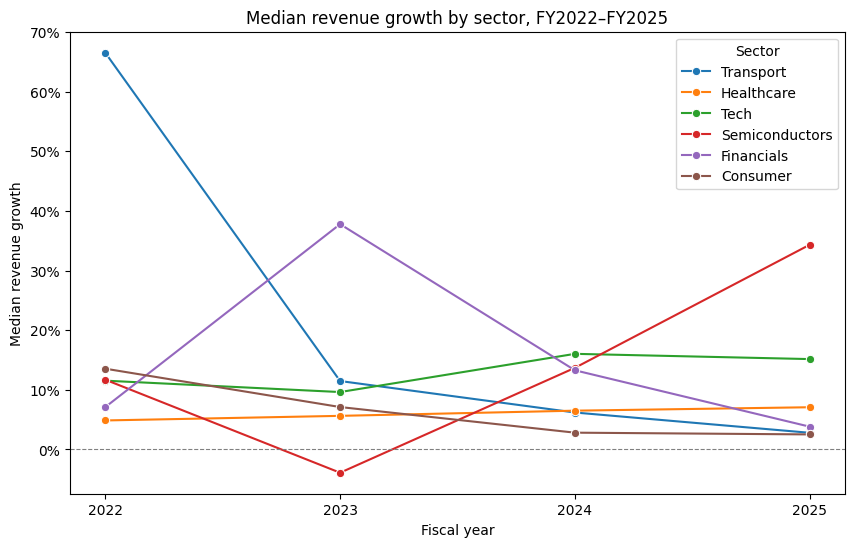

In [13]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=analysis_df,
    x="fiscalYear",
    y="revenue_growth",
    hue="sector",
    estimator="median",
    errorbar=None,
    marker="o",
)

plt.title("Median revenue growth by sector, FY2022–FY2025")
plt.xlabel("Fiscal year")
plt.ylabel("Median revenue growth")
plt.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.xticks([2022, 2023, 2024, 2025])
plt.legend(title="Sector")

plt.savefig("../images/q1_revenue_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## Q1 - How did revenue growth vary across sectors?

### What I expected

Before plotting, my expectations were:

- **Transport** would grow strongly, since the sector was hit hard by COVID in 2020–21 and had room to recover.
- **Financials** would rise around 2022–23, as central banks raised interest rates sharply to fight inflation.
- **Semiconductors** would rise in 2025, driven by AI demand.
- **Tech** would broadly mirror semiconductors, for the same reason.
- **Healthcare** might decline after the COVID period, as pandemic-related demand faded.
- **Consumer** I had no strong expectation for.

### What the chart shows

| Sector | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|
| Transport | 66% | 11% | 6% | 3% |
| Financials | 7% | 38% | 13% | 4% |
| Semiconductors | 12% | −4% | 14% | 34% |
| Tech | 12% | 10% | 16% | 15% |
| Consumer | 14% | 7% | 3% | 3% |
| Healthcare | 5% | 6% | 7% | 7% |

Each sector seemed to move in its own direction, with not much correlation between them.

Three sectors stand out. Transport starts highest and declines steadily toward zero. Financials spikes once, in 2023, then falls back. Semiconductors is the only sector to record an outright revenue decline (−4% in 2023) before climbing to the highest growth rate of any sector in 2025.

Two sectors barely move at all: Tech stays between 10% and 16% throughout, and Healthcare between 5% and 7%.

### Why

**Transport's 66% is recovery, not growth.** Airlines were still operating well below capacity in 2021. 2022 was the year travel came back, and growth measured from a collapsed base appears very large. The companies were returning to normal rather than exceeding it, which is why growth becomes flat to 3% once they arrive.

**The Financials spike is a consequence of how bank revenue is reported.** As explained in the data quality section, rising rates increased the gross interest banks collected, but interest paid also increased in parallel. Their revenue inflated without corresponding to the growth of the business.

**The semiconductor decline in 2023 is unrelated to AI.** PC and phone purchasing during covid increased demand, and 2023 was the correction. The AI wave then reversed the trend from 2024. It is important to note that this sector contains only three companies, so the line reflects Nvidia, AMD and Intel specifically rather than a broad sector.

**Consumer growth in 2022 was largely price, not volume.** Prices rose with inflation and revenue rose with them, without more goods being sold. The decline to 3% tracks inflation cooling rather than demand decreasing.

**Healthcare's stability is characteristic of a defensive sector.** Demand for medical care and medicines does not vary much with interest rates or the economic cycle.

### Where my expectations were wrong

**Tech did not mirror semiconductors.** I expected Tech to rise with the AI wave, but it is the flattest line on the chart after Healthcare.

This surprised me, because 2022 was full of tech layoffs and headlines about a "tech crash". But those headlines were about share prices, not sales. Tech share prices fell sharply in 2022, while tech revenue kept growing.

However, the two measure different things. A share price is what investors are willing to pay. When interest rates rose in 2022, safer investments started paying better returns, so investors were no longer willing to pay as much for profits that might arrive years later. Share prices fell without revenue falling. The layoffs came from companies having hired for a growth rate investors no longer believed in.

The lesson is that revenue describes the business, while share prices describe expectations about the business.

**Healthcare rose slightly instead of declining.** I expected a fall as COVID vaccine demand faded. That did happen, Pfizer and Moderna both saw revenue drop sharply. But the sector also contains insurers, hospitals and general pharmaceutical companies, which grew steadily. Because the median takes the middle value, two companies falling did not move the line. My reasoning was correct for part of the sector, however the median did not show it.

### Limitations

**The median hides what happens inside a sector.** Healthcare is the clearest case, as described above: the vaccine makers fell while the median rose. The same applies to Semiconductors, where Nvidia and Intel moved in opposite directions but appear as one line.

**Semiconductors contains only three companies.** A median of three values is fragile, and any claim about that line is really a claim about Nvidia, AMD and Intel individually.

**Fiscal years do not align across companies.** As noted in the data quality section, "FY2023" covers different twelve-month periods depending on the company, so each point carries a few months of timing noise.

**The Financials line should not be read as business growth**, for the reasons set out in the data quality section.